# Library Imports

In [ ]:
import os
from pathlib import Path
os.environ['DLClight']="True"
os.environ['PYTHONPYCACHEPREFIX'] = './tmp'
%matplotlib ipympl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image

import torch

if not torch.cuda.is_available():
    raise Exception("GPU not found!")

try:
    import deeplabcut
except Exception as e:
    print("Error importing deeplabcut!")
    print(e)
    
print("Dependencies successfully imported!")

Loading DLC 3.0.0rc10...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
Dependencies successfully imported!


In [3]:
import deeplabcut.utils.auxiliaryfunctions as auxiliaryfunctions
from deeplabcut.pose_estimation_pytorch.apis import (
    superanimal_analyze_images,
)
from deeplabcut.modelzoo import build_weight_init
from deeplabcut.modelzoo.utils import (
    create_conversion_table,
    read_conversion_table_from_csv,
)
from deeplabcut.modelzoo.video_inference import video_inference_superanimal
from deeplabcut.utils.pseudo_label import keypoint_matching

In [4]:
import time # for timing operations

# Project Setup

In [5]:
working_dir = Path.cwd().parent # should be DLC directory
print(working_dir)

/blue/adamdewan/gch22a.fsu/DLC


## Create new project OR load previous project
If loading a previous project, it is assumed that you have extracted frames and labeled them already. Skip to the "Load a previous project" heading. 

### Create a new project

#### Create video list for a new project

In [4]:
video_folder = working_dir.joinpath("Videos/p14_sensory_oxtrko_isolation")
video_list = []
for filename in os.listdir(video_folder):
    if filename.endswith((".mp4", ".asf", ".mov")): 
        video_list.append(os.path.join(video_folder, filename))

# print(video_list)

In [ ]:
# create new project in project directory: only do if wanting to crate a new project
project_dir = working_dir.joinpath("Projects")
print(project_dir)

config_path = deeplabcut.create_new_project("benchmarking",
                              "grace",
                              videos=video_list,              
                              working_directory=project_dir,
                              multianimal = False)
print(config_path)
# after project creation, ensure you modify the config.yaml file generated in the 
# project directory to include the correct bodyparts

/blue/adamdewan/gch22a.fsu/DLC/Projects
Project "/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking-grace-2025-09-13" already exists!
/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking-grace-2025-09-13/config.yaml


#### Extract frames via k means clustering

In [ ]:
# extract frames - settings for how many are in config file
deeplabcut.extract_frames(
    config_path,
    mode="automatic",
    algo="kmeans",
    crop=False,
    userfeedback=False
)

Config file read successfully.
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5321.06  seconds.
Extracting and downsampling... 78592  frames from the video.


78592it [00:17, 4575.49it/s]


Kmeans clustering ... (this might take a while)
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5338.77  seconds.
Extracting and downsampling... 80135  frames from the video.


80135it [00:18, 4363.81it/s]


Kmeans clustering ... (this might take a while)
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5254.47  seconds.
Extracting and downsampling... 74561  frames from the video.


...

79275it [00:12, 6172.47it/s]


Kmeans clustering ... (this might take a while)
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5240.31  seconds.
Extracting and downsampling... 77347  frames from the video.


77347it [00:13, 5722.67it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).


[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False]

#### Label frames (do this on a computer with access to a GUI)

In [ ]:
# label frames (can't do this in HiPerGator)
# download project, label frames on personal computer
deeplabcut.label_frames(config_path)

AttributeError: module 'deeplabcut' has no attribute 'label_frames'

### Load a previous project

In [ ]:
# load previous project: use this if working on an existing project 

project_dir = working_dir.joinpath("Projects")
print(project_dir)

project_name = "" ## project name

project_path = project_dir.joinpath(project_name)
print(project_path)

# ensure that project path starts with /blue/adamdewan, NOT /blue_adamdewan
config_path = project_path.joinpath("config.yaml")
print(config_path)

/blue/adamdewan/gch22a.fsu/DLC/Projects
/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13
/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13/config.yaml


## Check labels on frames - if labels are not okay, go back to labeling step

In [6]:
deeplabcut.check_labels(config_path, visualizeindividuals=True)

Creating images with labels by grace.


100%|██████████| 10/10 [00:00<00:00, 56.35it/s]

If all the labels are ok, then use the function 'create_training_dataset' to create the training dataset!


## Create training datasets - run on the computer where you want to train your model

In [1]:
# model settings 
superanimal_name = "superanimal_topviewmouse"
detector_name = "fasterrcnn_resnet50_fpn_v2"

In [34]:
# create base training dataset
base = 0
deeplabcut.create_training_dataset(
    config_path,
    Shuffles=[base],
    engine=deeplabcut.Engine.PYTORCH,
    userfeedback=False,
)

Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


[(0.5,
  0,
  (array([104,  68, 263, 197, 139,  34, 260, 175, 182,  10,   0, 259, 279,
          151,  32,   1,  13, 102,  56,  99, 203,  15, 164, 221, 107,  19,
           92, 105, 300,  74, 146, 162, 180, 209,  31, 125, 242, 160, 282,
           12, 141, 303, 140,  95,  58, 246, 184,  67, 132,  81,   7,  41,
           93, 298,  76, 167, 297,  83, 161, 296, 289, 120, 218, 294, 174,
           23, 302, 252, 280,  45, 229, 265, 230,  84,  65, 247,  98, 251,
           46, 124, 235,  37, 131, 199, 127, 273, 189, 136, 241, 143,  88,
          110,  85, 138,  63, 148,  55,  24, 240,  38, 147, 153, 234, 227,
           77, 249, 266, 244, 201,   9, 219,  78, 177,  64, 220, 121, 238,
          111, 239, 293,  54, 278, 281, 193, 176, 169,  18,  61, 159, 168,
            8, 126,  57, 267, 129,  27, 228,  97, 191,   3,  79,  33, 243,
           75, 253, 152, 204, 207,  89, 181, 290, 255]),
   array([248, 130, 156,  42, 285, 135, 115,  87,  39, 114,  25, 187, 166,
          119,  60, 149, 145,  

# 50% Training Fraction

### ImageNet transfer learning

In [8]:
intl_hrnet_w18 = 9
intl_hrnet_w32 = 10
intl_resnet_50 = 11
intl_resnet_101 = 12
intl_nets = ["hrnet_w18", "hrnet_w32", "resnet_50", "resnet_101"]

intl_shuffles = [intl_hrnet_w18, intl_hrnet_w32, intl_resnet_50, intl_resnet_101]

In [12]:
for shuffle, net in zip(intl_shuffles, intl_nets):
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        engine=deeplabcut.Engine.PYTORCH,
        userfeedback=False,
    )
    

You passed a split with the following fraction: 50%
You passed a split with the following fraction: 50%
You passed a split with the following fraction: 50%
You passed a split with the following fraction: 50%


In [13]:
## ImageNet transfer learning
for shuffle in intl_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=64,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device:

Time for 9: 309.1322603368899 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 10: 255.8727485310519 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 11: 179.44305082492065 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 12: 191.08302072505467 seconds


In [14]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=intl_shuffles, 
    plotting=True
)

Evaluation scorer: DLC_HrnetW18_benchmarkingSep4shuffle9_detector_best-10_snapshot_best-150


100%|██████████| 152/152 [00:02<00:00, 58.28it/s]


Evaluation results file: DLC_HrnetW18_benchmarkingSep4shuffle9_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW18_benchmarkingSep4shuffle9_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             3.42
train rmse_pcutoff     1.29
train mAP             80.99
train mAR             85.00
test rmse              7.37
test rmse_pcutoff      3.48
test mAP              55.04
test mAR              59.87
Name: (0.5, 9, 150, 10, 0.6), dtype: float64
Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle10_detector_best-10_snapshot_best-150


100%|██████████| 152/152 [00:02<00:00, 65.78it/s]


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle10_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle10_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             1.32
train rmse_pcutoff     1.11
train mAP             97.26
train mAR             97.83
test rmse              5.04
test rmse_pcutoff      3.17
test mAP              72.56
test mAR              77.60
Name: (0.5, 10, 150, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle11_detector_best-10_snapshot_best-110


100%|██████████| 152/152 [00:00<00:00, 219.57it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle11_detector_best-10_snapshot_best-110-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle11_detector_best-10_snapshot_best-110-results.csv (pcutoff: 0.6):
train rmse             1.03
train rmse_pcutoff     0.91
train mAP             97.61
train mAR             98.09
test rmse              4.01
test rmse_pcutoff      2.84
test mAP              79.03
test mAR              83.60
Name: (0.5, 11, 110, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet101_benchmarkingSep4shuffle12_detector_best-10_snapshot_best-140


100%|██████████| 152/152 [00:00<00:00, 173.98it/s]


Evaluation results file: DLC_Resnet101_benchmarkingSep4shuffle12_detector_best-10_snapshot_best-140-results.csv
Evaluation results for DLC_Resnet101_benchmarkingSep4shuffle12_detector_best-10_snapshot_best-140-results.csv (pcutoff: 0.6):
train rmse             1.42
train rmse_pcutoff     0.96
train mAP             96.83
train mAR             97.70
test rmse              5.29
test rmse_pcutoff      2.80
test mAP              72.75
test mAR              77.07
Name: (0.5, 12, 140, 10, 0.6), dtype: float64


### SuperAnimal Transfer Learning

In [17]:
# can only to SATL with resnet_50 and hrnet_w32 (of the resnets and hrnets)
satl_hrnet_w32 = 13
satl_resnet_50 = 14
satl_shuffles = [satl_hrnet_w32, satl_resnet_50]

satl_nets = ["hrnet_w32", "resnet_50"]

# detector_name = "fasterrcnn_resnet50_fpn_v2"

for shuffle, net in zip(satl_shuffles, satl_nets):
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=detector_name,
        with_decoder=False,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        engine=deeplabcut.Engine.PYTORCH,
        weight_init=weight_init,
        userfeedback=False,
    )
    


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


In [18]:
# create 4 shuffles w/ exact same split and varying network types 

for shuffle in satl_shuffles:
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=32,
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device:

Time for 13: 285.8643247761065 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 14: 176.81809227506164 seconds


In [19]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=satl_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle13_detector_best-10_snapshot_best-120


100%|██████████| 152/152 [00:02<00:00, 66.58it/s]


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle13_detector_best-10_snapshot_best-120-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle13_detector_best-10_snapshot_best-120-results.csv (pcutoff: 0.6):
train rmse             1.15
train rmse_pcutoff     1.12
train mAP             99.22
train mAR             99.41
test rmse              3.33
test rmse_pcutoff      2.93
test mAP              84.04
test mAR              87.80
Name: (0.5, 13, 120, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle14_detector_best-10_snapshot_best-80


100%|██████████| 152/152 [00:00<00:00, 217.98it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle14_detector_best-10_snapshot_best-80-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle14_detector_best-10_snapshot_best-80-results.csv (pcutoff: 0.6):
train rmse             1.14
train rmse_pcutoff     1.06
train mAP             99.02
train mAR             99.41
test rmse              3.77
test rmse_pcutoff      3.03
test mAP              81.78
test mAR              85.87
Name: (0.5, 14, 80, 10, 0.6), dtype: float64


### SuperAnimal Naive Fine Tuning

In [20]:
sanft_hrnet_w32 = 15
sanft_resnet_50 = 16
sanft_shuffles = [sanft_hrnet_w32, sanft_resnet_50]
sanft_nets = ["hrnet_w32", "resnet_50"]

Before checking trainset temp_dataset
Before checking testset temp_dataset


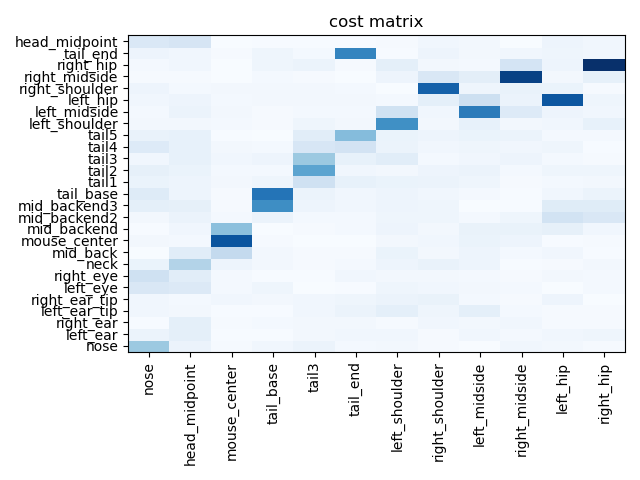

In [12]:
# I don't know if it will matter that I put hrnet_w32 and a specific detector in here.
# don't see why it should for keypoint matching? define model again in weight initialization and model training 
keypoint_matching(
    config_path,
    superanimal_name,
    "hrnet_w32",
    "fasterrcnn_resnet50_fpn_v2",
    copy_images=True,
)

conversion_table_path = project_path / "memory_replay" / "conversion_table.csv"
confusion_matrix_path = project_path / "memory_replay" / "confusion_matrix.png"

# You can visualize the pseudo predictions, or do pose embedding clustering etc.
pseudo_prediction_path = project_path / "memory_replay" / "pseudo_predictions.json"

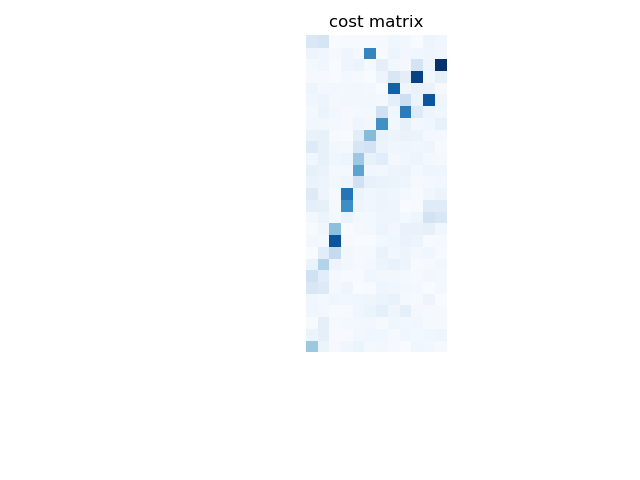

In [13]:
## display the confusion matrix 

confusion_matrix_image = Image.open(confusion_matrix_path)

plt.imshow(confusion_matrix_image)
plt.axis('off')  # Hide the axes for better view
plt.show()

In [14]:
# display the conversion table
df = pd.read_csv(conversion_table_path)
df = df.dropna()

df

,gt,MasterName
0,nose,nose
7,head_midpoint,neck
9,mouse_center,mouse_center
13,tail_base,tail_base
15,tail3,tail2
19,left_shoulder,left_shoulder
20,left_midside,left_midside
21,left_hip,left_hip
22,right_shoulder,right_shoulder
23,right_midside,right_midside


In [15]:
# create the conversion table and add to project's config file
create_conversion_table(
    config=config_path,
    super_animal=superanimal_name,
    project_to_super_animal=read_conversion_table_from_csv(
        conversion_table_path
    ),
)

ConversionTable(super_animal='superanimal_topviewmouse', project_bodyparts=['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'left_hip', 'right_hip'], super_animal_bodyparts=['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip', 'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center', 'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1', 'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside', 'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end', 'head_midpoint'], table={'nose': 'nose', 'head_midpoint': 'neck', 'mouse_center': 'mouse_center', 'tail_base': 'tail_base', 'tail3': 'tail2', 'left_shoulder': 'left_shoulder', 'left_midside': 'left_midside', 'left_hip': 'left_hip', 'right_shoulder': 'right_shoulder', 'right_midside': 'right_midside', 'right_hip': 'right_hip', 'tail_end': 'tail_end'})

In [25]:
for shuffle, net in zip(sanft_shuffles, sanft_nets):               
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=detector_name,
        with_decoder=True,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        engine=deeplabcut.Engine.PYTORCH,
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        weight_init=weight_init,
        userfeedback=False,
    )

Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


In [26]:
for shuffle in sanft_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=64,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle,
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time 
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  colormode: RGB
  inference:
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
    normalize_images: True
  train:
    affine:
      p: 0.5
      scaling: [1.0, 1.0]
      rotation: 30
      translation: 0
    gaussian_noise: 12.75
    normalize_images: True
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device: auto
  model:
    type: FasterRCNN
    variant: fasterrcnn_resnet50_fpn_v2
    box_score_thresh: 0.6
    freeze_bn_stats: True
    freeze_bn_weight

Time for 15: 239.86621280992404 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 16: 179.7142092490103 seconds


In [27]:
deeplabcut.evaluate_network(
    config_path,
    Shuffles=sanft_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle15_detector_best-10_snapshot_best-110


100%|██████████| 152/152 [00:02<00:00, 68.14it/s]


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle15_detector_best-10_snapshot_best-110-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle15_detector_best-10_snapshot_best-110-results.csv (pcutoff: 0.6):
train rmse             3.13
train rmse_pcutoff     2.36
train mAP             87.81
train mAR             89.80
test rmse              5.45
test rmse_pcutoff      3.37
test mAP              76.25
test mAR              79.80
Name: (0.5, 15, 110, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle16_detector_best-10_snapshot_best-150


100%|██████████| 152/152 [00:00<00:00, 218.65it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle16_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle16_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             4.07
train rmse_pcutoff     2.41
train mAP             82.19
train mAR             84.67
test rmse              6.51
test rmse_pcutoff      3.30
test mAP              68.05
test mAR              72.07
Name: (0.5, 16, 150, 10, 0.6), dtype: float64


# Adjust Training Split and Repeat

# 75% Training Fraction

In [30]:
# edit config for training fraction
edits = {
    "TrainingFraction": 0.75
}
auxiliaryfunctions.edit_config(config_path, edits)

{'Task': 'benchmarking', 'scorer': 'grace', 'date': 'Sep4', 'multianimalproject': False, 'identity': None, 'project_path': '/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13', 'engine': 'pytorch', 'video_sets': {'/blue/adamdewan/gch22a.fsu/DLC/Videos/p14_sensory_oxtrko_isolation/p14_isolation_20240304_4.mov': {'crop': '0, 190, 0, 160'}, '/blue/adamdewan/gch22a.fsu/DLC/Videos/p14_sensory_oxtrko_isolation/p14_isolation_20231220_3.mov': {'crop': '0, 180, 0, 186'}, '/blue/adamdewan/gch22a.fsu/DLC/Videos/p14_sensory_oxtrko_isolation/p14_isolation_20240304_1.mov': {'crop': '0, 160, 0, 170'}, '/blue/adamdewan/gch22a.fsu/DLC/Videos/p14_sensory_oxtrko_isolation/p14_isolation_20231222_5.mov': {'crop': '0, 160, 0, 180'}, '/blue/adamdewan/gch22a.fsu/DLC/Videos/p14_sensory_oxtrko_isolation/p14_isolation_20231220_6.mov': {'crop': '0, 180, 0, 176'}, '/blue/adamdewan/gch22a.fsu/DLC/Videos/p14_sensory_oxtrko_isolation/p14_isolation_20231220_8.mov': {'crop': '0, 170, 0, 190'}

In [32]:
base = 17 # base for adjusted training split
deeplabcut.create_training_dataset(
    config_path,
    Shuffles=[base],
    engine=deeplabcut.Engine.PYTORCH,
    userfeedback=False,
)

INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


[(0.75,
  17,
  (array([264, 240,  94,  60, 299,  42, 269, 280, 139,  57, 301, 158,  39,
           82,  73,  79,  65, 105, 225, 263,  77, 132, 276,  24,   9, 218,
          167, 262, 210, 148, 213,  70,  15, 237, 113, 266,   2, 188, 226,
          284, 230, 140, 208,  59, 211,   8, 168,  88, 206, 169,  71, 294,
          285, 111, 150, 245,  13, 136, 120,  75, 204, 260, 217, 109,  26,
           14, 253, 256,  32,  54, 199,  51, 219,  25,  93,  95,  69, 134,
          127, 281,  19, 203, 259,  96, 216, 273,  11, 270, 193,  53, 149,
           90, 196, 101,  35, 205,   4, 247, 296, 128, 197, 198, 182, 137,
          221, 286, 290,  16, 129, 215, 185, 179, 110,  12, 241,  23, 223,
           91,   0, 114, 141, 298,  10,  43, 246, 232, 254,  45,  84, 261,
          191, 231,  41, 130, 252, 122,  52,  85, 143, 190, 291,  67,  21,
          177, 144, 275, 228,  76,  28, 178,  17, 133,  86,  34, 100, 292,
           36, 184, 235, 302, 279, 124,  58,   5,  49, 272, 244, 274, 153,
           

### ImageNet transfer learning

In [44]:
intl_hrnet_w18 = 19
intl_hrnet_w32 = 20
intl_resnet_50 = 21
intl_resnet_101 = 22
intl_nets = ["hrnet_w18", "hrnet_w32", "resnet_50", "resnet_101"]

intl_shuffles = [intl_hrnet_w18, intl_hrnet_w32, intl_resnet_50, intl_resnet_101]

In [43]:
for shuffle, net in zip(intl_shuffles, intl_nets):
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        engine=deeplabcut.Engine.PYTORCH,
        userfeedback=False,
    )

INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


In [45]:
## ImageNet transfer learning
for shuffle in intl_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=64,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device:

Time for 19: 346.8202157949563 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 20: 329.7915338660823 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 21: 244.66175162501168 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 22: 254.509842991014 seconds


In [46]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=intl_shuffles, 
    plotting=True
)

Evaluation scorer: DLC_HrnetW18_benchmarkingSep4shuffle19_detector_best-10_snapshot_best-150


100%|██████████| 76/76 [00:01<00:00, 59.32it/s]


Evaluation results file: DLC_HrnetW18_benchmarkingSep4shuffle19_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW18_benchmarkingSep4shuffle19_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             2.09
train rmse_pcutoff     1.44
train mAP             92.35
train mAR             94.03
test rmse              4.68
test rmse_pcutoff      3.02
test mAP              74.62
test mAR              77.89
Name: (0.75, 19, 150, 10, 0.6), dtype: float64
Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle20_detector_best-10_snapshot_best-130


100%|██████████| 76/76 [00:01<00:00, 67.13it/s] 


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle20_detector_best-10_snapshot_best-130-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle20_detector_best-10_snapshot_best-130-results.csv (pcutoff: 0.6):
train rmse             1.54
train rmse_pcutoff     1.16
train mAP             96.45
train mAR             97.39
test rmse              4.20
test rmse_pcutoff      2.93
test mAP              78.50
test mAR              82.89
Name: (0.75, 20, 130, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle21_detector_best-10_snapshot_best-140


100%|██████████| 76/76 [00:00<00:00, 221.88it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle21_detector_best-10_snapshot_best-140-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle21_detector_best-10_snapshot_best-140-results.csv (pcutoff: 0.6):
train rmse             1.09
train rmse_pcutoff     0.83
train mAP             97.59
train mAR             98.14
test rmse              3.79
test rmse_pcutoff      2.62
test mAP              83.25
test mAR              85.66
Name: (0.75, 21, 140, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet101_benchmarkingSep4shuffle22_detector_best-10_snapshot_best-130


100%|██████████| 76/76 [00:00<00:00, 178.61it/s]


Evaluation results file: DLC_Resnet101_benchmarkingSep4shuffle22_detector_best-10_snapshot_best-130-results.csv
Evaluation results for DLC_Resnet101_benchmarkingSep4shuffle22_detector_best-10_snapshot_best-130-results.csv (pcutoff: 0.6):
train rmse             1.27
train rmse_pcutoff     0.95
train mAP             96.06
train mAR             97.04
test rmse              3.31
test rmse_pcutoff      2.53
test mAP              85.16
test mAR              87.89
Name: (0.75, 22, 130, 10, 0.6), dtype: float64


### SuperAnimal Transfer Learning

In [47]:
# can only to SATL with resnet_50 and hrnet_w32 (of the resnets and hrnets)
satl_hrnet_w32 = 23
satl_resnet_50 = 24
satl_shuffles = [satl_hrnet_w32, satl_resnet_50]

satl_nets = ["hrnet_w32", "resnet_50"]


for shuffle, net in zip(satl_shuffles, satl_nets):
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=detector_name,
        with_decoder=False,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        engine=deeplabcut.Engine.PYTORCH,
        weight_init=weight_init,
        userfeedback=False,
    )
    


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


In [48]:

for shuffle in satl_shuffles:
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=32,
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device:

Time for 23: 369.18484806700144 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 24: 249.94521208002698 seconds


In [49]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=satl_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle23_detector_best-10_snapshot_best-40


100%|██████████| 76/76 [00:01<00:00, 67.65it/s] 


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle23_detector_best-10_snapshot_best-40-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle23_detector_best-10_snapshot_best-40-results.csv (pcutoff: 0.6):
train rmse             1.89
train rmse_pcutoff     1.61
train mAP             95.53
train mAR             96.95
test rmse              3.13
test rmse_pcutoff      2.70
test mAP              86.35
test mAR              89.34
Name: (0.75, 23, 40, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle24_detector_best-10_snapshot_best-150


100%|██████████| 76/76 [00:00<00:00, 218.99it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle24_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle24_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             0.95
train rmse_pcutoff     0.89
train mAP             97.83
train mAR             98.76
test rmse              3.06
test rmse_pcutoff      2.53
test mAP              86.87
test mAR              89.21
Name: (0.75, 24, 150, 10, 0.6), dtype: float64


### SuperAnimal Naive Fine Tuning

In [51]:
sanft_hrnet_w32 = 25
sanft_resnet_50 = 26
sanft_shuffles = [sanft_hrnet_w32, sanft_resnet_50]
sanft_nets = ["hrnet_w32", "resnet_50"]

Before checking trainset temp_dataset
Before checking testset temp_dataset


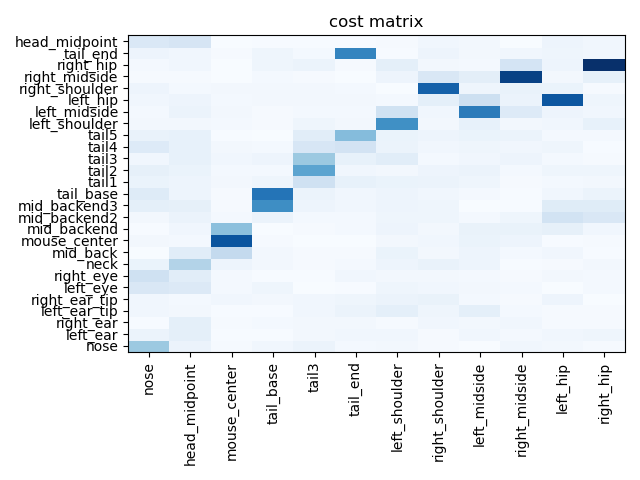

In [12]:
# I don't know if it will matter that I put hrnet_w32 and a specific detector in here.
# don't see why it should for keypoint matching? define model again in weight initialization and model training 
keypoint_matching(
    config_path,
    superanimal_name,
    "hrnet_w32",
    "fasterrcnn_resnet50_fpn_v2",
    copy_images=True,
)

conversion_table_path = project_path / "memory_replay" / "conversion_table.csv"
confusion_matrix_path = project_path / "memory_replay" / "confusion_matrix.png"

# You can visualize the pseudo predictions, or do pose embedding clustering etc.
pseudo_prediction_path = project_path / "memory_replay" / "pseudo_predictions.json"

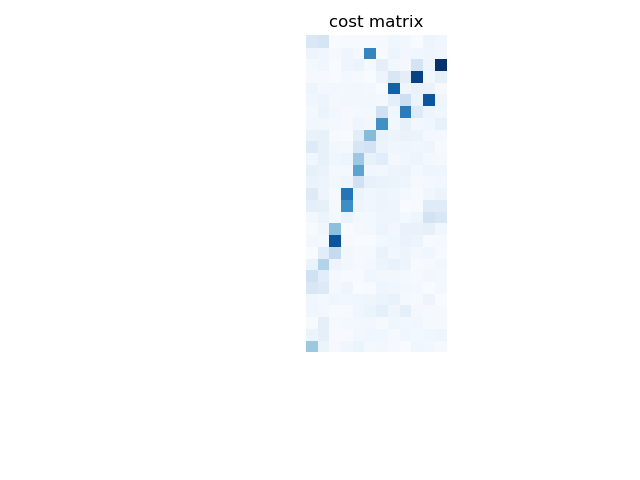

In [13]:
## display the confusion matrix 

confusion_matrix_image = Image.open(confusion_matrix_path)

plt.imshow(confusion_matrix_image)
plt.axis('off')  # Hide the axes for better view
plt.show()

In [14]:
# display the conversion table
df = pd.read_csv(conversion_table_path)
df = df.dropna()

df

,gt,MasterName
0,nose,nose
7,head_midpoint,neck
9,mouse_center,mouse_center
13,tail_base,tail_base
15,tail3,tail2
19,left_shoulder,left_shoulder
20,left_midside,left_midside
21,left_hip,left_hip
22,right_shoulder,right_shoulder
23,right_midside,right_midside


In [15]:
# create the conversion table and add to project's config file
create_conversion_table(
    config=config_path,
    super_animal=superanimal_name,
    project_to_super_animal=read_conversion_table_from_csv(
        conversion_table_path
    ),
)

ConversionTable(super_animal='superanimal_topviewmouse', project_bodyparts=['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'left_hip', 'right_hip'], super_animal_bodyparts=['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip', 'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center', 'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1', 'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside', 'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end', 'head_midpoint'], table={'nose': 'nose', 'head_midpoint': 'neck', 'mouse_center': 'mouse_center', 'tail_base': 'tail_base', 'tail3': 'tail2', 'left_shoulder': 'left_shoulder', 'left_midside': 'left_midside', 'left_hip': 'left_hip', 'right_shoulder': 'right_shoulder', 'right_midside': 'right_midside', 'right_hip': 'right_hip', 'tail_end': 'tail_end'})

In [52]:
for shuffle, net in zip(sanft_shuffles, sanft_nets):               
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=detector_name,
        with_decoder=True,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        engine=deeplabcut.Engine.PYTORCH,
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        weight_init=weight_init,
        userfeedback=False,
    )

INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 75%


In [53]:
for shuffle in sanft_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=64,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle,
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time 
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  colormode: RGB
  inference:
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
    normalize_images: True
  train:
    affine:
      p: 0.5
      scaling: [1.0, 1.0]
      rotation: 30
      translation: 0
    gaussian_noise: 12.75
    normalize_images: True
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device: auto
  model:
    type: FasterRCNN
    variant: fasterrcnn_resnet50_fpn_v2
    box_score_thresh: 0.6
    freeze_bn_stats: True
    freeze_bn_weight

Time for 25: 314.5289171639597 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 26: 252.22158781799953 seconds


In [54]:
deeplabcut.evaluate_network(
    config_path,
    Shuffles=sanft_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle25_detector_best-10_snapshot_best-80


100%|██████████| 76/76 [00:01<00:00, 69.35it/s] 


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle25_detector_best-10_snapshot_best-80-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle25_detector_best-10_snapshot_best-80-results.csv (pcutoff: 0.6):
train rmse             2.83
train rmse_pcutoff     2.45
train mAP             87.64
train mAR             90.13
test rmse              4.07
test rmse_pcutoff      3.17
test mAP              82.26
test mAR              85.00
Name: (0.75, 25, 80, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle26_detector_best-10_snapshot_best-150


100%|██████████| 76/76 [00:00<00:00, 219.68it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle26_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle26_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             3.99
train rmse_pcutoff     2.34
train mAP             83.75
train mAR             86.59
test rmse              4.13
test rmse_pcutoff      2.67
test mAP              81.01
test mAR              83.42
Name: (0.75, 26, 150, 10, 0.6), dtype: float64


# 90% Training Fraction

In [55]:
base = 27 # base for adjusted training split
deeplabcut.create_training_dataset(
    config_path,
    Shuffles=[base],
    engine=deeplabcut.Engine.PYTORCH,
    userfeedback=False,
)

INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


[(0.9,
  27,
  (array([263,  73, 181, 132, 101,  33,  78,   6,  86, 253,  28, 286,  66,
          236, 169,  46,   4, 254, 291,  69, 161,  67,   9,  21, 164,  25,
            2, 252, 201, 232, 233,  90, 224, 170, 122,  60, 117, 245, 257,
          280, 146,  23, 298, 250,  32,  50, 223, 158, 123, 259,  91,  82,
           34,  72,  45, 134, 104,  40, 120, 215, 121, 276, 221, 193, 284,
           99, 145,  87, 228, 135, 261, 208,  18, 173, 219, 288, 247,  65,
           20, 138, 283, 287, 112, 301,  63,  36,  49, 282, 185, 302, 152,
          240, 241,  84, 179, 116, 162, 157, 248,  42, 274, 106,  41, 103,
          270, 255, 209,  26, 156, 150, 199,  77, 153,  96,  11, 249, 198,
          163,  79,  97,  74, 260,  43,   0, 148, 205,   8, 174,  56, 269,
          194, 107, 115, 160,  54, 267, 139, 141, 297,  93, 197, 239, 102,
           29,   1, 118,  15, 272, 110, 178,   7, 154,  22, 214, 188,  57,
          151,  16, 251, 128, 213,  19, 113, 229,  44, 244, 204, 271, 172,
          30

### ImageNet transfer learning

In [14]:
base=27
intl_hrnet_w18 = 28
intl_hrnet_w32 = 29
intl_resnet_50 = 30
intl_resnet_101 = 31
intl_nets = ["hrnet_w18", "hrnet_w32", "resnet_50", "resnet_101"]

intl_shuffles = [intl_hrnet_w18, intl_hrnet_w32, intl_resnet_50, intl_resnet_101]

In [57]:
for shuffle, net in zip(intl_shuffles, intl_nets):
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        engine=deeplabcut.Engine.PYTORCH,
        userfeedback=False,
    )

INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


In [ ]:
## ImageNet transfer learning
for shuffle in intl_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=64,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device:

Time for 28: 391.321373670944 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 29: 385.14307001105044 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

Time for 30: 278.78068843402434 seconds


/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': ['bbox_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_para

In [8]:
# 70 more epochs of 31 (got cut off)
deeplabcut.train_network(
    config_path, 
    epochs=70,
    detector_epochs=0,
    save_epochs=10,
    batch_size=64,
    displayiters=10,
    shuffle=31,
    snapshot_path="/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13/dlc-models-pytorch/iteration-0/benchmarkingSep4-trainset90shuffle31/train/snapshot-080.pt"
)


Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device: auto
  model:
    type: FasterRCNN
    freeze_bn_stats: True
    freeze_bn_weights: False
    variant: fasterrcnn_resnet50_fpn_v2
  runner:
    type:

In [11]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=intl_shuffles, 
    plotting=True
)

Evaluation scorer: DLC_HrnetW18_benchmarkingSep4shuffle28_detector_best-10_snapshot_best-150


100%|██████████| 31/31 [00:00<00:00, 66.58it/s]


Evaluation results file: DLC_HrnetW18_benchmarkingSep4shuffle28_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW18_benchmarkingSep4shuffle28_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             1.92
train rmse_pcutoff     1.32
train mAP             93.89
train mAR             95.33
test rmse              4.17
test rmse_pcutoff      3.01
test mAP              71.49
test mAR              74.67
Name: (0.9, 28, 150, 10, 0.6), dtype: float64
Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle29_detector_best-10_snapshot_best-150


100%|██████████| 31/31 [00:00<00:00, 75.20it/s] 


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle29_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle29_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             1.57
train rmse_pcutoff     1.22
train mAP             96.90
train mAR             97.76
test rmse              5.33
test rmse_pcutoff      2.84
test mAP              74.06
test mAR              77.00
Name: (0.9, 29, 150, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle30_detector_best-10_snapshot_best-120


100%|██████████| 31/31 [00:00<00:00, 247.70it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle30_detector_best-10_snapshot_best-120-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle30_detector_best-10_snapshot_best-120-results.csv (pcutoff: 0.6):
train rmse             1.00
train rmse_pcutoff     0.83
train mAP             97.76
train mAR             98.35
test rmse              3.60
test rmse_pcutoff      2.47
test mAP              79.36
test mAR              80.67
Name: (0.9, 30, 120, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet101_benchmarkingSep4shuffle31_detector_best-10_snapshot_best-100


100%|██████████| 31/31 [00:00<00:00, 192.61it/s]


Evaluation results file: DLC_Resnet101_benchmarkingSep4shuffle31_detector_best-10_snapshot_best-100-results.csv
Evaluation results for DLC_Resnet101_benchmarkingSep4shuffle31_detector_best-10_snapshot_best-100-results.csv (pcutoff: 0.6):
train rmse             1.29
train rmse_pcutoff     0.97
train mAP             97.58
train mAR             98.24
test rmse              4.21
test rmse_pcutoff      2.50
test mAP              78.27
test mAR              81.33
Name: (0.9, 31, 100, 10, 0.6), dtype: float64


### SuperAnimal Transfer Learning

In [15]:
# can only to SATL with resnet_50 and hrnet_w32 (of the resnets and hrnets)
satl_hrnet_w32 = 32
satl_resnet_50 = 33
satl_shuffles = [satl_hrnet_w32, satl_resnet_50]

satl_nets = ["hrnet_w32", "resnet_50"]


for shuffle, net in zip(satl_shuffles, satl_nets):
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=detector_name,
        with_decoder=False,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        engine=deeplabcut.Engine.PYTORCH,
        weight_init=weight_init,
        userfeedback=False,
    )
    


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


In [16]:

for shuffle in satl_shuffles:
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=32,
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device:

Time for 32: 413.49048333393876 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 33: 289.18176941398997 seconds


In [17]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=satl_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle32_detector_best-10_snapshot_best-40


100%|██████████| 31/31 [00:00<00:00, 75.01it/s] 


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle32_detector_best-10_snapshot_best-40-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle32_detector_best-10_snapshot_best-40-results.csv (pcutoff: 0.6):
train rmse             1.70
train rmse_pcutoff     1.44
train mAP             96.24
train mAR             97.28
test rmse              3.55
test rmse_pcutoff      2.62
test mAP              80.10
test mAR              82.67
Name: (0.9, 32, 40, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle33_detector_best-10_snapshot_best-100


100%|██████████| 31/31 [00:00<00:00, 245.93it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle33_detector_best-10_snapshot_best-100-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle33_detector_best-10_snapshot_best-100-results.csv (pcutoff: 0.6):
train rmse             0.88
train rmse_pcutoff     0.85
train mAP             98.39
train mAR             99.19
test rmse              3.45
test rmse_pcutoff      2.63
test mAP              84.10
test mAR              85.67
Name: (0.9, 33, 100, 10, 0.6), dtype: float64


### SuperAnimal Naive Fine Tuning

In [18]:
sanft_hrnet_w32 = 34
sanft_resnet_50 = 35
sanft_shuffles = [sanft_hrnet_w32, sanft_resnet_50]
sanft_nets = ["hrnet_w32", "resnet_50"]

Before checking trainset temp_dataset
Before checking testset temp_dataset


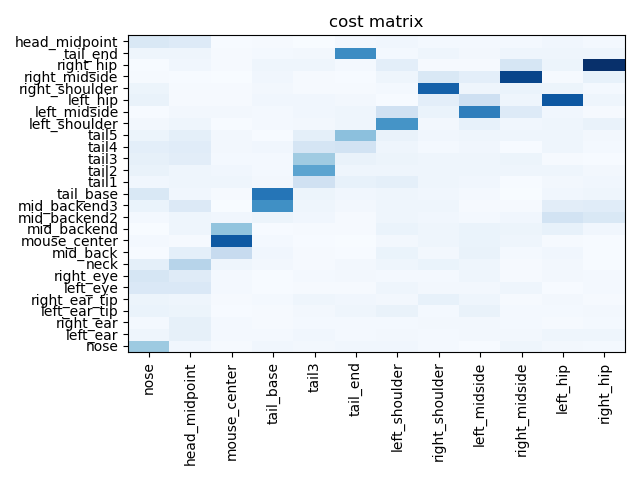

In [19]:
# I don't know if it will matter that I put hrnet_w32 and a specific detector in here.
# don't see why it should for keypoint matching? define model again in weight initialization and model training 
keypoint_matching(
    config_path,
    superanimal_name,
    "hrnet_w32",
    "fasterrcnn_resnet50_fpn_v2",
    copy_images=True,
)

conversion_table_path = project_path / "memory_replay" / "conversion_table.csv"
confusion_matrix_path = project_path / "memory_replay" / "confusion_matrix.png"

# You can visualize the pseudo predictions, or do pose embedding clustering etc.
pseudo_prediction_path = project_path / "memory_replay" / "pseudo_predictions.json"

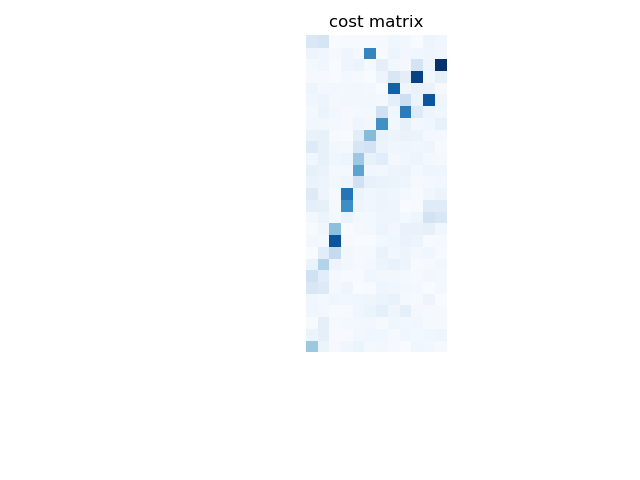

In [13]:
## display the confusion matrix 

confusion_matrix_image = Image.open(confusion_matrix_path)

plt.imshow(confusion_matrix_image)
plt.axis('off')  # Hide the axes for better view
plt.show()

In [14]:
# display the conversion table
df = pd.read_csv(conversion_table_path)
df = df.dropna()

df

,gt,MasterName
0,nose,nose
7,head_midpoint,neck
9,mouse_center,mouse_center
13,tail_base,tail_base
15,tail3,tail2
19,left_shoulder,left_shoulder
20,left_midside,left_midside
21,left_hip,left_hip
22,right_shoulder,right_shoulder
23,right_midside,right_midside


In [15]:
# create the conversion table and add to project's config file
create_conversion_table(
    config=config_path,
    super_animal=superanimal_name,
    project_to_super_animal=read_conversion_table_from_csv(
        conversion_table_path
    ),
)

ConversionTable(super_animal='superanimal_topviewmouse', project_bodyparts=['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'left_hip', 'right_hip'], super_animal_bodyparts=['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip', 'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center', 'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1', 'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside', 'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end', 'head_midpoint'], table={'nose': 'nose', 'head_midpoint': 'neck', 'mouse_center': 'mouse_center', 'tail_base': 'tail_base', 'tail3': 'tail2', 'left_shoulder': 'left_shoulder', 'left_midside': 'left_midside', 'left_hip': 'left_hip', 'right_shoulder': 'right_shoulder', 'right_midside': 'right_midside', 'right_hip': 'right_hip', 'tail_end': 'tail_end'})

In [20]:
for shuffle, net in zip(sanft_shuffles, sanft_nets):               
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=detector_name,
        with_decoder=True,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        engine=deeplabcut.Engine.PYTORCH,
        net_type=f"top_down_{net}",
        detector_type=detector_name,
        weight_init=weight_init,
        userfeedback=False,
    )

INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 90%


In [21]:
for shuffle in sanft_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=64,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle,
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time 
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  colormode: RGB
  inference:
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
    normalize_images: True
  train:
    affine:
      p: 0.5
      scaling: [1.0, 1.0]
      rotation: 30
      translation: 0
    gaussian_noise: 12.75
    normalize_images: True
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device: auto
  model:
    type: FasterRCNN
    variant: fasterrcnn_resnet50_fpn_v2
    box_score_thresh: 0.6
    freeze_bn_stats: True
    freeze_bn_weight

Time for 34: 359.0838631710503 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 35: 291.04250817000866 seconds


In [22]:
deeplabcut.evaluate_network(
    config_path,
    Shuffles=sanft_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle34_detector_best-10_snapshot_best-110


100%|██████████| 31/31 [00:00<00:00, 77.08it/s] 


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle34_detector_best-10_snapshot_best-110-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle34_detector_best-10_snapshot_best-110-results.csv (pcutoff: 0.6):
train rmse             2.71
train rmse_pcutoff     2.23
train mAP             90.74
train mAR             93.01
test rmse              5.62
test rmse_pcutoff      3.23
test mAP              72.34
test mAR              74.33
Name: (0.9, 34, 110, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle35_detector_best-10_snapshot_best-150


100%|██████████| 31/31 [00:00<00:00, 235.32it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle35_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle35_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             3.66
train rmse_pcutoff     2.33
train mAP             82.63
train mAR             85.77
test rmse              5.62
test rmse_pcutoff      2.78
test mAP              73.76
test mAR              77.00
Name: (0.9, 35, 150, 10, 0.6), dtype: float64


# K-Fold Cross Validation: Test selected model on multiple splits to ensure consistent performance

In [ ]:
test_shuffles = [36, 37, 38, 39]
# create multiple shuffles w/ 75% training fraction 

weight_init = build_weight_init(
    cfg=auxiliaryfunctions.read_config(config_path), 
    super_animal=superanimal_name,
    model_name="resnet_50",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    with_decoder=False,
)

deeplabcut.create_training_dataset(
    config_path, 
    Shuffles=test_shuffles, 
    net_type="top_down_resnet_50",
    detector_type="fasterrcnn_resnet50_fpn_v2",
    weight_init=weight_init,
    engine=deeplabcut.Engine.PYTORCH,
    userfeedback=False,
)

[(0.75,
  36,
  (array([ 11,  92, 212,  41, 134, 159,  97,   9, 224,   6, 242, 163, 226,
            0, 139,  36,  73, 183, 293, 238,  49, 292, 209, 125,  57, 246,
           54,  12, 236, 259, 222, 249, 291, 254,  82,  20, 144,  67, 127,
           90, 174, 124, 177, 196,  79,  91,  18, 145, 296, 105, 279, 151,
          244,   3,  89, 217, 285,  66, 289, 300,  44, 215, 103, 235, 301,
          110,  75, 164, 115, 154, 243, 233,  31,  72,  87,  93, 120, 168,
          278,  26, 166,   4, 101, 136, 169,  34,  78,  32,  52, 267, 187,
          240, 182, 232, 260, 117, 173, 295, 122, 175,  10, 152,  86,  50,
          207, 213, 162, 171, 128,  74, 156,  70, 141, 203,  53, 221, 109,
           14,  25, 303, 193, 268,  59, 218, 211, 253, 135,  76,   5, 102,
           22,  62, 210,  17, 230,  61,  51, 191,  63, 170, 189, 298, 185,
          239, 247, 263, 286,  33, 149, 275,  21, 142, 192, 288,  95, 190,
          195, 245,   2, 227,  85, 269, 107, 200, 148, 219,  64,   8, 197,
          1

In [10]:
for shuffle in test_shuffles:
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        detector_epochs=10,
        epochs=150,
        save_epochs=10,
        batch_size=64,
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device: auto
  model:
    type: FasterRCNN
    freeze_bn_stats: True
    freeze_bn_weights: False
    variant: fasterrcnn_resnet50_fpn_v2
  runner:
    type:

Time for 36: 337.1898160970304 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 37: 252.56451130914502 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 38: 249.72838032897562 seconds


Loading detector checkpoint from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2.pt
/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/pose_estimation_pytorch/data/transforms.py:51: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  warnings.warn(
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.

Time for 39: 251.4113076601643 seconds


In [11]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=test_shuffles
)

Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle36_detector_best-10_snapshot_best-40


100%|██████████| 76/76 [00:00<00:00, 227.20it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle36_detector_best-10_snapshot_best-40-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle36_detector_best-10_snapshot_best-40-results.csv (pcutoff: 0.6):
train rmse             1.72
train rmse_pcutoff     1.23
train mAP             95.83
train mAR             97.12
test rmse              4.54
test rmse_pcutoff      3.43
test mAP              79.99
test mAR              83.68
Name: (0.75, 36, 40, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle37_detector_best-10_snapshot_best-40


100%|██████████| 76/76 [00:00<00:00, 223.42it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle37_detector_best-10_snapshot_best-40-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle37_detector_best-10_snapshot_best-40-results.csv (pcutoff: 0.6):
train rmse             1.41
train rmse_pcutoff     1.15
train mAP             96.26
train mAR             97.57
test rmse              3.14
test rmse_pcutoff      2.54
test mAP              85.61
test mAR              88.29
Name: (0.75, 37, 40, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle38_detector_best-10_snapshot_best-150


100%|██████████| 76/76 [00:00<00:00, 225.87it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle38_detector_best-10_snapshot_best-150-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle38_detector_best-10_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             1.06
train rmse_pcutoff     0.94
train mAP             97.36
train mAR             98.23
test rmse              2.90
test rmse_pcutoff      2.47
test mAP              87.97
test mAR              90.39
Name: (0.75, 38, 150, 10, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle39_detector_best-10_snapshot_best-70


100%|██████████| 76/76 [00:00<00:00, 217.91it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle39_detector_best-10_snapshot_best-70-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle39_detector_best-10_snapshot_best-70-results.csv (pcutoff: 0.6):
train rmse             1.26
train rmse_pcutoff     1.08
train mAP             97.09
train mAR             98.19
test rmse              3.70
test rmse_pcutoff      3.03
test mAP              80.58
test mAR              84.87
Name: (0.75, 39, 70, 10, 0.6), dtype: float64


# Other useful code snippets

#### Continue training from a previous snapshot

In [ ]:
# continue training from last snapshot to increase performance
# set epochs and detector_epochs to the number of additional epochs you would like to perform
# snapshot_path is to the best/most recent snapshot 
deeplabcut.train_network(
    config_path, 
    epochs=100,
    save_epochs=10,
    batch_size=64,
    displayiters=10,
    shuffle=imagenet_transfer_learning_shuffle,
    snapshot_path="/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking-grace-2025-09-04/dlc-models-pytorch/iteration-0/benchmarkingSep4-trainset95shuffle0/train/snapshot-best-050.pt"
)

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device: